In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
d = pd.read_excel('Data_Train.xlsx')
d

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [3]:
d.describe

<bound method NDFrame.describe of            Airline Date_of_Journey    Source Destination  \
0           IndiGo      24/03/2019  Banglore   New Delhi   
1        Air India       1/05/2019   Kolkata    Banglore   
2      Jet Airways       9/06/2019     Delhi      Cochin   
3           IndiGo      12/05/2019   Kolkata    Banglore   
4           IndiGo      01/03/2019  Banglore   New Delhi   
...            ...             ...       ...         ...   
10678     Air Asia       9/04/2019   Kolkata    Banglore   
10679    Air India      27/04/2019   Kolkata    Banglore   
10680  Jet Airways      27/04/2019  Banglore       Delhi   
10681      Vistara      01/03/2019  Banglore   New Delhi   
10682    Air India       9/05/2019     Delhi      Cochin   

                       Route Dep_Time  Arrival_Time Duration Total_Stops  \
0                  BLR → DEL    22:20  01:10 22 Mar   2h 50m    non-stop   
1      CCU → IXR → BBI → BLR    05:50         13:15   7h 25m     2 stops   
2      DEL → LKO 

In [4]:
d.info

<bound method DataFrame.info of            Airline Date_of_Journey    Source Destination  \
0           IndiGo      24/03/2019  Banglore   New Delhi   
1        Air India       1/05/2019   Kolkata    Banglore   
2      Jet Airways       9/06/2019     Delhi      Cochin   
3           IndiGo      12/05/2019   Kolkata    Banglore   
4           IndiGo      01/03/2019  Banglore   New Delhi   
...            ...             ...       ...         ...   
10678     Air Asia       9/04/2019   Kolkata    Banglore   
10679    Air India      27/04/2019   Kolkata    Banglore   
10680  Jet Airways      27/04/2019  Banglore       Delhi   
10681      Vistara      01/03/2019  Banglore   New Delhi   
10682    Air India       9/05/2019     Delhi      Cochin   

                       Route Dep_Time  Arrival_Time Duration Total_Stops  \
0                  BLR → DEL    22:20  01:10 22 Mar   2h 50m    non-stop   
1      CCU → IXR → BBI → BLR    05:50         13:15   7h 25m     2 stops   
2      DEL → LKO → 

In [5]:
d.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [7]:
d.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [8]:
d.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

In [9]:
d['Date_of_Journey'] = pd.to_datetime(d['Date_of_Journey'],format="%d/%m/%Y")

In [10]:
#drop the missing values
d.dropna(inplace=True)

In [11]:
#extract day.month ,year from date time using dt
d['Day'] = d['Date_of_Journey'].dt.day
d['Month'] = d['Date_of_Journey'].dt.month
d["Year"] = d['Date_of_Journey'].dt.year

In [12]:
d.drop('Date_of_Journey',axis=1,inplace=True)

In [13]:
d['Dep_hour'] = d['Dep_Time'].str.split(':').str[0].astype(int)
d['Dep_min'] = d['Dep_Time'].str.split(':').str[1].astype(int)

In [18]:
# extract the arrival hour and arrival min from the arrival time column
d['Arrival_hour'] = d['Arrival_Time'].str.split(' ').str[0].str.split(':').str[0].astype(int)
d['Arrival_min'] = d['Arrival_Time'].str.split(' ').str[0].str.split(':').str[1].astype(int)

In [19]:
d.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019,16,50,21,35


In [20]:
# extract the duration hour
d['Duration_hour'] = d['Duration'].str.split(' ').str[0]
d['Duration_min'] = d['Duration'].str.split(' ').str[1]

In [21]:
d.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hour,Duration_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10,2h,50m
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15,7h,25m
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019,9,25,4,25,19h,NaN
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019,18,5,23,30,5h,25m
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019,16,50,21,35,4h,45m


In [22]:
d.drop('Additional_Info',axis=1,inplace=True,errors='ignore')

In [23]:
d.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Price,Day,Month,Year,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hour,Duration_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,3897,24,3,2019,22,20,1,10,2h,50m
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,7662,1,5,2019,5,50,13,15,7h,25m
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,13882,9,6,2019,9,25,4,25,19h,NaN
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,6218,12,5,2019,18,5,23,30,5h,25m
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,13302,1,3,2019,16,50,21,35,4h,45m


In [24]:
d['Total_Stops'].value_counts()

Total_Stops
1 stop      5625
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64

In [27]:
d['Total_Stops'] = d['Total_Stops'].replace('non-stop','0 stop')

In [28]:
d['Total_Stops'].value_counts()

Total_Stops
1 stop     5625
0 stop     3491
2 stops    1520
3 stops      45
4 stops       1
Name: count, dtype: int64

In [29]:
# convert total stops into integer type
d['Total_Stops'] = d['Total_Stops'].str.split(' ').str[0].astype(int)

In [30]:
d['Route'].unique()

array(['BLR → DEL', 'CCU → IXR → BBI → BLR', 'DEL → LKO → BOM → COK',
       'CCU → NAG → BLR', 'BLR → NAG → DEL', 'CCU → BLR',
       'BLR → BOM → DEL', 'DEL → BOM → COK', 'DEL → BLR → COK',
       'MAA → CCU', 'CCU → BOM → BLR', 'DEL → AMD → BOM → COK',
       'DEL → PNQ → COK', 'DEL → CCU → BOM → COK', 'BLR → COK → DEL',
       'DEL → IDR → BOM → COK', 'DEL → LKO → COK',
       'CCU → GAU → DEL → BLR', 'DEL → NAG → BOM → COK',
       'CCU → MAA → BLR', 'DEL → HYD → COK', 'CCU → HYD → BLR',
       'DEL → COK', 'CCU → DEL → BLR', 'BLR → BOM → AMD → DEL',
       'BOM → DEL → HYD', 'DEL → MAA → COK', 'BOM → HYD',
       'DEL → BHO → BOM → COK', 'DEL → JAI → BOM → COK',
       'DEL → ATQ → BOM → COK', 'DEL → JDH → BOM → COK',
       'CCU → BBI → BOM → BLR', 'BLR → MAA → DEL',
       'DEL → GOI → BOM → COK', 'DEL → BDQ → BOM → COK',
       'CCU → JAI → BOM → BLR', 'CCU → BBI → BLR', 'BLR → HYD → DEL',
       'DEL → TRV → COK', 'CCU → IXR → DEL → BLR',
       'DEL → IXU → BOM → COK', 'CCU 

In [31]:
d['Route_1'] = d['Route'].str.split('→').str[0].str.strip()
d['Route_2'] = d['Route'].str.split('→').str[0].str.strip()
d['Route_3'] = d['Route'].str.split('→').str[0].str.strip()
d['Route_4'] = d['Route'].str.split('→').str[0].str.strip()
d['Route_5'] = d['Route'].str.split('→').str[0].str.strip()

In [32]:
d.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Price,Day,...,Dep_min,Arrival_hour,Arrival_min,Duration_hour,Duration_min,Route_1,Route_2,Route_3,Route_4,Route_5
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,3897,24,...,20,1,10,2h,50m,BLR,BLR,BLR,BLR,BLR
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,7662,1,...,50,13,15,7h,25m,CCU,CCU,CCU,CCU,CCU
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2,13882,9,...,25,4,25,19h,NaN,DEL,DEL,DEL,DEL,DEL
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1,6218,12,...,5,23,30,5h,25m,CCU,CCU,CCU,CCU,CCU
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1,13302,1,...,50,21,35,4h,45m,BLR,BLR,BLR,BLR,BLR


In [33]:
d['Route_1'] = d['Route'].fillna('None')
d['Route_2'] = d['Route'].fillna('None')
d['Route_3'] = d['Route'].fillna('None')
d['Route_4'] = d['Route'].fillna('None')
d['Route_5'] = d['Route'].fillna('None')

In [34]:
d.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Price,Day,...,Dep_min,Arrival_hour,Arrival_min,Duration_hour,Duration_min,Route_1,Route_2,Route_3,Route_4,Route_5
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,3897,24,...,20,1,10,2h,50m,BLR → DEL,BLR → DEL,BLR → DEL,BLR → DEL,BLR → DEL
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,7662,1,...,50,13,15,7h,25m,CCU → IXR → BBI → BLR,CCU → IXR → BBI → BLR,CCU → IXR → BBI → BLR,CCU → IXR → BBI → BLR,CCU → IXR → BBI → BLR
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2,13882,9,...,25,4,25,19h,NaN,DEL → LKO → BOM → COK,DEL → LKO → BOM → COK,DEL → LKO → BOM → COK,DEL → LKO → BOM → COK,DEL → LKO → BOM → COK
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1,6218,12,...,5,23,30,5h,25m,CCU → NAG → BLR,CCU → NAG → BLR,CCU → NAG → BLR,CCU → NAG → BLR,CCU → NAG → BLR
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1,13302,1,...,50,21,35,4h,45m,BLR → NAG → DEL,BLR → NAG → DEL,BLR → NAG → DEL,BLR → NAG → DEL,BLR → NAG → DEL


In [35]:
#remove route colume
d.drop('Route',axis=1, inplace=True)

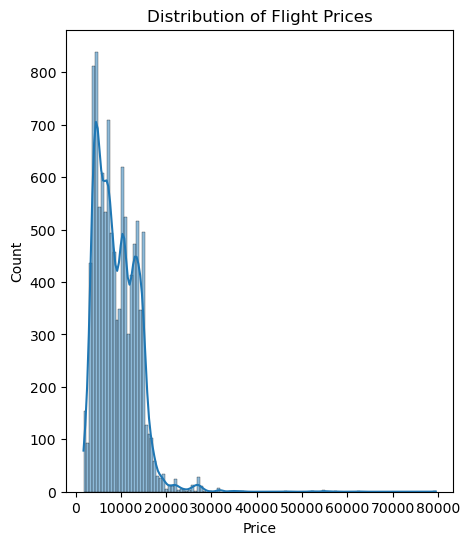

In [37]:
plt.figure(figsize=(5,6))
sns.histplot(d['Price'],kde=True)
plt.title('Distribution of Flight Prices')
plt.show()

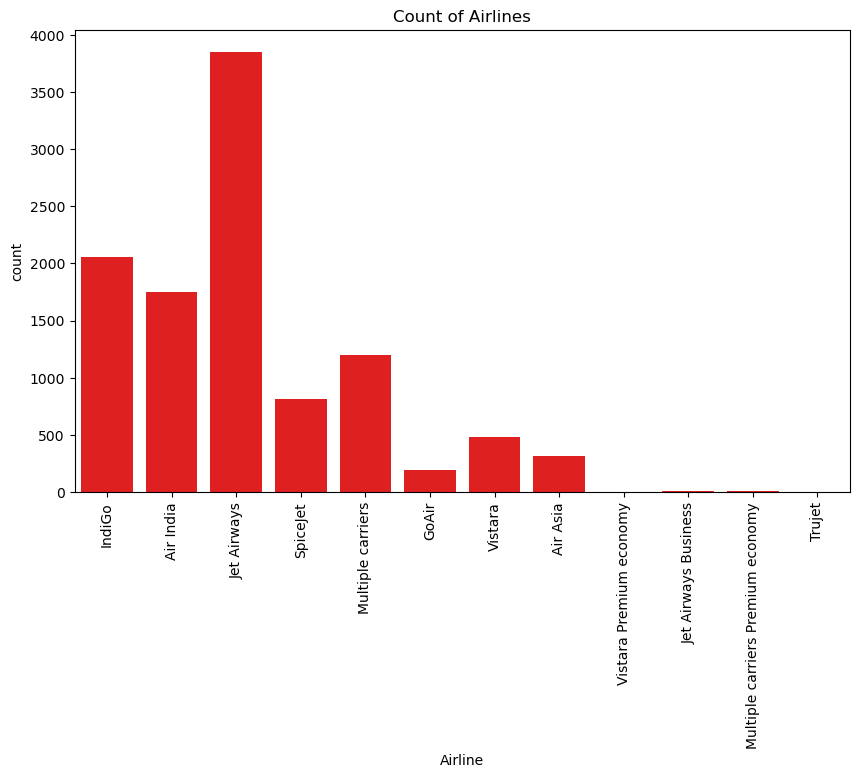

In [47]:
# plot the count of airlines
plt.figure(figsize=(10,6))
sns.countplot(x='Airline',data=d,color='red')
plt.title('Count of Airlines')
plt.xticks(rotation=90)
plt.show()

In [42]:
d['Airline'].value_counts()

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1751
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

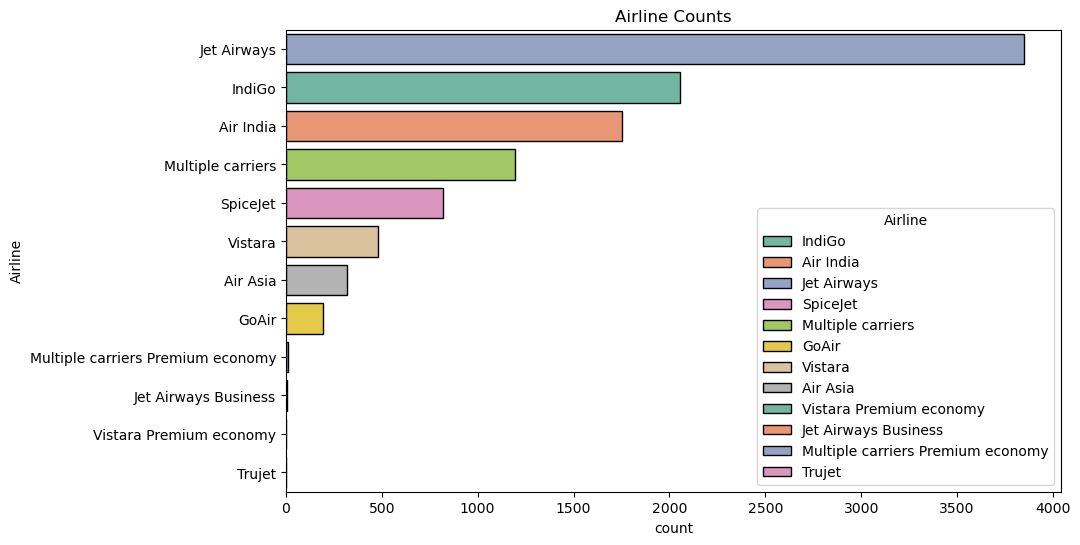

In [49]:
# plot the airline counts
plt.figure(figsize=(10, 6))
# make horizontal bar plot of airline counts
sns.countplot(y=d['Airline'], order=d['Airline'].value_counts().index,hue=d['Airline'],edgecolor='black',palette='Set2',dodge=False,legend=True)
plt.title('Airline Counts')
plt.show()
 

In [51]:
#step 5: feature encoding

# encode the airline column using one hot encoding

d = pd.get_dummies(d, columns=['Airline'], drop_first=True)

In [52]:
d.head()

,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Price,Day,Month,Year,...,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy
0,Banglore,New Delhi,22:20,01:10 22 Mar,2h 50m,0,3897,24,3,2019,...,False,True,False,False,False,False,False,False,False,False
1,Kolkata,Banglore,05:50,13:15,7h 25m,2,7662,1,5,2019,...,False,False,False,False,False,False,False,False,False,False
2,Delhi,Cochin,09:25,04:25 10 Jun,19h,2,13882,9,6,2019,...,False,False,True,False,False,False,False,False,False,False
3,Kolkata,Banglore,18:05,23:30,5h 25m,1,6218,12,5,2019,...,False,True,False,False,False,False,False,False,False,False
4,Banglore,New Delhi,16:50,21:35,4h 45m,1,13302,1,3,2019,...,False,True,False,False,False,False,False,False,False,False


In [55]:
# convert all airline boolean datatype to int
d = d.astype({col: 'int64' for col in d.select_dtypes(include=['bool']).columns})

In [56]:
d.head()

,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Price,Day,Month,Year,...,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy
0,Banglore,New Delhi,22:20,01:10 22 Mar,2h 50m,0,3897,24,3,2019,...,0,1,0,0,0,0,0,0,0,0
1,Kolkata,Banglore,05:50,13:15,7h 25m,2,7662,1,5,2019,...,0,0,0,0,0,0,0,0,0,0
2,Delhi,Cochin,09:25,04:25 10 Jun,19h,2,13882,9,6,2019,...,0,0,1,0,0,0,0,0,0,0
3,Kolkata,Banglore,18:05,23:30,5h 25m,1,6218,12,5,2019,...,0,1,0,0,0,0,0,0,0,0
4,Banglore,New Delhi,16:50,21:35,4h 45m,1,13302,1,3,2019,...,0,1,0,0,0,0,0,0,0,0


In [57]:
# all categorical columns convert into label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_cols = d.select_dtypes(include=['object']).columns
for col in categorical_cols:
    d[col] = le.fit_transform(d[col])

In [58]:
d.head()

,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Price,Day,Month,Year,...,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy
0,0,5,211,233,240,0,3897,24,3,2019,...,0,1,0,0,0,0,0,0,0,0
1,3,0,31,906,336,2,7662,1,5,2019,...,0,0,0,0,0,0,0,0,0,0
2,2,1,70,413,106,2,13882,9,6,2019,...,0,0,1,0,0,0,0,0,0,0
3,3,0,164,1324,311,1,6218,12,5,2019,...,0,1,0,0,0,0,0,0,0,0
4,0,5,149,1237,303,1,13302,1,3,2019,...,0,1,0,0,0,0,0,0,0,0


In [ ]:
#check central tendency of the price column
print('Mean:',d['Price'].mean())
print('Median:',d['Price'].median())
print('Mode:',d['Price'].mode())

Mean: 9087.21456656057
Median: 8372.0
Mode: 0    10262
Name: Price, dtype: int64


In [68]:
# model 1 linear regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
lr=LinearRegression()
X = d.drop('Price', axis=1)
y = d['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R2 Score:', r2_score(y_test, y_pred))

Mean Absolute Error: 2031.6639633396624
Mean Squared Error: 8619222.710841117
R2 Score: 0.6002597070863469


In [69]:
# model 2 Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred_dt))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred_dt))
print('R2 Score:', r2_score(y_test, y_pred_dt))

Mean Absolute Error: 1323.2572453595383
Mean Squared Error: 5937016.813681693
R2 Score: 0.72465442421515


In [70]:
# model 3 svm
from sklearn.svm import SVR
svr = SVR(kernel='linear', C=10, gamma='scale')
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred_svr))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred_svr))
print('R2 Score:', r2_score(y_test, y_pred_svr))

Mean Absolute Error: 2032.1983593918085
Mean Squared Error: 10846435.764131226
R2 Score: 0.4969665415456206


In [71]:
# model 4 knn
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred_knn))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred_knn))
print('R2 Score:', r2_score(y_test, y_pred_knn))

Mean Absolute Error: 1798.7976914677897
Mean Squared Error: 9503557.710913533
R2 Score: 0.5592462254973272


In [72]:
# model 5: random forest regressor
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred_rf))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred_rf))
print('R2 Score:', r2_score(y_test, y_pred_rf))

Mean Absolute Error: 1158.5947949570707
Mean Squared Error: 3556156.7429337376
R2 Score: 0.8350733951590315


In [73]:
# make a dataframe to compare the performance of all the models
model_comparison = pd.DataFrame({'Model': ['Linear Regression', 'Decision Tree Regressor', 'SVR', 'KNN Regressor', 'Random Forest Regressor'],
                                 'MAE': [mean_absolute_error(y_test, y_pred), mean_absolute_error(y_test, y_pred_dt), mean_absolute_error(y_test, y_pred_svr), mean_absolute_error(y_test, y_pred_knn), mean_absolute_error(y_test, y_pred_rf)],
                                 'MSE': [mean_squared_error(y_test, y_pred), mean_squared_error(y_test, y_pred_dt), mean_squared_error(y_test, y_pred_svr), mean_squared_error(y_test, y_pred_knn), mean_squared_error(y_test, y_pred_rf)],
                                 'R2 Score': [r2_score(y_test, y_pred), r2_score(y_test, y_pred_dt), r2_score(y_test, y_pred_svr), r2_score(y_test, y_pred_knn), r2_score(y_test, y_pred_rf)]})
model_comparison

,Model,MAE,MSE,R2 Score
0,Linear Regression,2031.663963,8.619223e+06,0.600260
1,Decision Tree Regressor,1323.257245,5.937017e+06,0.724654
2,SVR,2032.198359,1.084644e+07,0.496967
3,KNN Regressor,1798.797691,9.503558e+06,0.559246
4,Random Forest Regressor,1158.594795,3.556157e+06,0.835073


In [74]:
import joblib

joblib.dump(rf, 'flight_price_model.pkl')
joblib.dump(X.columns, 'model_features.pkl')

['model_features.pkl']